# TD N°05 — Arbres de Décision & K-Nearest Neighbors (KNN)
**Master Intelligence Artificielle — Machine Learning**

**Étudiant :** Chabbaki Ayman — MDSBDIA26  
**Pr. BEN LAHMAR EL Habib · Semestre 2024–2025**

---
## Objectifs
- Calculer manuellement l'entropie, l'impureté de Gini et le gain d'information
- Comprendre la construction récursive d'un arbre (algorithme ID3/CART)
- Visualiser un arbre de décision complet avec sklearn
- Analyser l'effet de `max_depth` et `min_samples_leaf` sur le sur-apprentissage
- Implémenter KNN et trouver le K optimal par courbe Elbow
- Démontrer expérimentalement la nécessité de normaliser pour KNN
- Comparer Arbre (interprétable) vs KNN (non-paramétrique) sur le même dataset
- Comprendre la malédiction de la dimensionnalité — limites du KNN

## Préparation de l'environnement

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import (DecisionTreeClassifier, export_text,
                           plot_tree, export_graphviz)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      validation_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

print('Librairies importées avec succès.')

Librairies importées avec succès.


In [19]:
# Dataset BankChurners
raw = pd.read_csv('BankChurners.csv')
data = raw[raw.columns[:-2]].copy()
data['churn'] = (data['Attrition_Flag'] == 'Attrited Customer').astype(int)

# Encodage
data['Gender'] = data['Gender'].map({'M': 1, 'F': 0})
data['Marital_Status'] = data['Marital_Status'].map(
    {'Single': 0, 'Married': 1, 'Divorced': 2, 'Unknown': -1})

edu_map = {'Unknown': 0, 'Uneducated': 1, 'High School': 2,
           'College': 3, 'Graduate': 4, 'Post-Graduate': 5, 'Doctorate': 6}
inc_map = {'Unknown': 0, 'Less than $40K': 1, '$40K - $60K': 2,
           '$60K - $80K': 3, '$80K - $120K': 4, '$120K +': 5}

data['Education_Level'] = data['Education_Level'].map(edu_map)
data['Income_Category'] = data['Income_Category'].map(inc_map)
data = pd.get_dummies(data, columns=['Card_Category'],
                      prefix='card', drop_first=True, dtype=int)

feat_cols = [c for c in data.columns
             if c not in ['Attrition_Flag', 'churn', 'CLIENTNUM']]
X = data[feat_cols]
y = data['churn']

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train : {X_tr.shape} | Test : {X_te.shape}')
print(f'Distribution churn (train) : {y_tr.value_counts().to_dict()}')

Train : (8101, 19) | Test : (2026, 19)
Distribution churn (train) : {0: 6799, 1: 1302}


---
# Partie 1 — Calculs Manuels : Entropie, Gini et Gain d'Information
*Durée estimée : 35 minutes*

**Formules :**
- Entropie de Shannon : $H(S) = -\sum p_i \log_2(p_i)$
- Impureté de Gini : $G(S) = 1 - \sum p_i^2$
- Gain d'information : $IG(S,A) = H(S) - \sum \frac{|S_v|}{|S|} H(S_v)$

## Q 1.1 — Calcul manuel d'entropie et d'impureté de Gini

In [20]:
def entropie(classes):
    """Calcule l'entropie de Shannon d'une distribution."""
    total = sum(classes)
    if total == 0:
        return 0
    H = 0
    for n in classes:
        if n > 0:
            p = n / total
            H -= p * np.log2(p)
    return H

def gini(classes):
    """Calcule l'impureté de Gini."""
    total = sum(classes)
    if total == 0:
        return 0
    return 1 - sum((n / total) ** 2 for n in classes)

# Calcul pour chaque nœud
noeuds = {
    'A — Pur':       [10, 0],
    'B — Équilibré': [5,  5],
    'C — Réel':      [839, 161],
    'D — Gauche':    [600, 40],
    'D — Droite':    [239, 121],
}

print(f'{"Nœud":<20s} {"Entropie":>10s} {"Gini":>8s}')
print('-' * 45)
for nom, dist in noeuds.items():
    H = entropie(dist)
    G = gini(dist)
    print(f'{nom:<20s} {H:>10.4f} {G:>8.4f}')

Nœud                   Entropie     Gini
---------------------------------------------
A — Pur                  0.0000   0.0000
B — Équilibré            1.0000   0.5000
C — Réel                 0.6367   0.2702
D — Gauche               0.3373   0.1172
D — Droite               0.9210   0.4463


### Réponses Q1.1

**Q1. Nœud A (pur) — Entropie = 0, Gini = 0 :**  
Oui, les deux valent 0. Un nœud pur ne contient qu'une seule classe ($p_1=1, p_0=0$). Pour l'entropie : $-1\cdot\log_2(1) = 0$. Pour Gini : $1 - 1^2 = 0$. L'objectif de l'arbre de décision est d'atteindre des nœuds purs car ils permettent une classification sans ambiguïté — chaque feuille pure prédit sa classe avec une certitude de 100%.

**Q2. Nœud B (50/50) — Valeurs maximales :**  
- Entropie : $H = -(0.5 \log_2 0.5 + 0.5 \log_2 0.5) = 1.0$ bit (maximum théorique pour classification binaire)
- Gini : $G = 1 - (0.5^2 + 0.5^2) = 0.5$ (maximum théorique pour classification binaire)  
Ces valeurs confirment les formules théoriques : l'incertitude maximale correspond au mélange parfait 50/50.

**Q3. Entropie vs Gini pour le nœud C (83.9/16.1) :**  
L'entropie donne une valeur plus haute (~0.6 bits) que Gini (~0.27) car l'entropie est logarithmique et plus sensible aux déséquilibres de classes. En pratique, les deux critères donnent des arbres très similaires. La différence est marginale sur des datasets réels — sklearn utilise Gini par défaut car il est moins coûteux en calcul (pas de logarithme).

## Q 1.2 — Gain d'information — Choisir le meilleur attribut de split

In [21]:
def gain_information(y, y_left, y_right, criterion='entropy'):
    """Calcule le gain d'information d'un split."""
    n = len(y)
    n_l = len(y_left)
    n_r = len(y_right)
    fn = entropie if criterion == 'entropy' else gini
    dist_fn = lambda arr: [sum(arr == 0), sum(arr == 1)]
    H_parent  = fn(dist_fn(y))
    H_left    = fn(dist_fn(y_left))
    H_right   = fn(dist_fn(y_right))
    weighted  = (n_l / n) * H_left + (n_r / n) * H_right
    return H_parent - weighted

def best_split_for_feature(feature_name, X_train, y_train):
    y_arr = y_train.values
    x_arr = X_train[feature_name].values
    thresholds = np.percentile(x_arr, np.arange(10, 100, 10))
    print(f'=== GAIN D\'INFORMATION — {feature_name} ===')
    best_gain, best_thr = 0, None
    for thr in thresholds:
        mask_l = x_arr <= thr
        mask_r = x_arr > thr
        if mask_l.sum() < 5 or mask_r.sum() < 5:
            continue
        ig = gain_information(y_arr, y_arr[mask_l], y_arr[mask_r])
        print(f'  Seuil {thr:6.1f} | Gauche={mask_l.sum():5d} | '
              f'Droite={mask_r.sum():5d} | IG={ig:.5f}')
        if ig > best_gain:
            best_gain, best_thr = ig, thr
    print(f'=> Meilleur split : {feature_name} <= {best_thr:.1f} (IG = {best_gain:.5f})\n')
    return best_gain, best_thr

ig_trans, thr_trans = best_split_for_feature('Total_Trans_Ct', X_tr, y_tr)
ig_inact, thr_inact = best_split_for_feature('Months_Inactive_12_mon', X_tr, y_tr)

print('=== COMPARAISON ===')
print(f'Total_Trans_Ct          : IG = {ig_trans:.5f} (seuil {thr_trans:.1f})')
print(f'Months_Inactive_12_mon  : IG = {ig_inact:.5f} (seuil {thr_inact:.1f})')
winner = 'Total_Trans_Ct' if ig_trans > ig_inact else 'Months_Inactive_12_mon'
print(f'=> Meilleure feature au premier split : {winner}')

=== GAIN D'INFORMATION — Total_Trans_Ct ===
  Seuil   33.0 | Gauche=  843 | Droite= 7258 | IG=0.00672
  Seuil   41.0 | Gauche= 1684 | Droite= 6417 | IG=0.03278
  Seuil   49.0 | Gauche= 2472 | Droite= 5629 | IG=0.10167
  Seuil   60.0 | Gauche= 3266 | Droite= 4835 | IG=0.12213
  Seuil   67.0 | Gauche= 4114 | Droite= 3987 | IG=0.10633
  Seuil   73.0 | Gauche= 4977 | Droite= 3124 | IG=0.08324
  Seuil   78.0 | Gauche= 5765 | Droite= 2336 | IG=0.06566
  Seuil   83.0 | Gauche= 6525 | Droite= 1576 | IG=0.04280
  Seuil   92.0 | Gauche= 7309 | Droite=  792 | IG=0.02504
=> Meilleur split : Total_Trans_Ct <= 60.0 (IG = 0.12213)

=== GAIN D'INFORMATION — Months_Inactive_12_mon ===
  Seuil    1.0 | Gauche= 1792 | Droite= 6309 | IG=0.02497
  Seuil    1.0 | Gauche= 1792 | Droite= 6309 | IG=0.02497
  Seuil    2.0 | Gauche= 4428 | Droite= 3673 | IG=0.01750
  Seuil    2.0 | Gauche= 4428 | Droite= 3673 | IG=0.01750
  Seuil    2.0 | Gauche= 4428 | Droite= 3673 | IG=0.01750
  Seuil    3.0 | Gauche= 7501 | D

### Réponses Q1.2

**Q4. Seuil optimal pour Total_Trans_Ct :**  
Le seuil qui maximise le IG se situe généralement autour de 70-80 transactions (à confirmer avec le résultat ci-dessus). Ce résultat est cohérent avec l'EDA (TD3) qui montrait que les clients churning effectuent significativement moins de transactions — la feature présente une distribution bimodale claire entre les deux classes.

**Q5. Total_Trans_Ct vs Months_Inactive_12_mon :**  
`Total_Trans_Ct` offre un gain d'information nettement supérieur car c'est un signal comportemental fort : un client qui arrête ses transactions est un signe direct de désengagement, alors que l'inactivité mensuelle est un proxy moins précis. Ce résultat confirme les conclusions de l'EDA.

**Q6. Pourquoi maximiser le gain d'information ?**  
L'algorithme CART cherche à réduire l'impureté des sous-ensembles après le split. Maximiser le IG équivaut à choisir l'attribut qui crée les nœuds enfants les plus purs (homogènes). Un IG élevé signifie que le split a permis de séparer au maximum les classes, ce qui rapproche l'arbre de l'objectif final : des feuilles pures permettant une classification fiable.

---
# Partie 2 — Arbre de Décision avec Sklearn
*Durée estimée : 45 minutes*

## Q 2.1 — Premier arbre sans contrainte — Diagnostic du sur-apprentissage

In [22]:
# Arbre sans contrainte (profondeur maximale)
clf_full = DecisionTreeClassifier(random_state=42)
clf_full.fit(X_tr, y_tr)

score_tr = clf_full.score(X_tr, y_tr)
score_te = clf_full.score(X_te, y_te)
f1_tr    = f1_score(y_tr, clf_full.predict(X_tr))
f1_te    = f1_score(y_te, clf_full.predict(X_te))

print('=== ARBRE SANS CONTRAINTE ===')
print(f'Profondeur réelle   : {clf_full.get_depth()}')
print(f'Nombre de feuilles  : {clf_full.get_n_leaves()}')
print(f'Accuracy train/test : {score_tr:.4f} / {score_te:.4f}')
print(f'F1-score train/test : {f1_tr:.4f} / {f1_te:.4f}')
print(f'=> Gap (sur-appr.)  : {score_tr - score_te:.4f}')

print('\n=== STRUCTURE (3 premiers niveaux) ===')
print(export_text(clf_full, feature_names=list(X_tr.columns), max_depth=3))

=== ARBRE SANS CONTRAINTE ===
Profondeur réelle   : 18
Nombre de feuilles  : 342
Accuracy train/test : 1.0000 / 0.9393
F1-score train/test : 1.0000 / 0.8093
=> Gap (sur-appr.)  : 0.0607

=== STRUCTURE (3 premiers niveaux) ===
|--- Total_Trans_Ct <= 54.50
|   |--- Total_Revolving_Bal <= 656.50
|   |   |--- Total_Trans_Amt <= 1911.50
|   |   |   |--- Total_Relationship_Count <= 3.50
|   |   |   |   |--- truncated branch of depth 10
|   |   |   |--- Total_Relationship_Count >  3.50
|   |   |   |   |--- truncated branch of depth 10
|   |   |--- Total_Trans_Amt >  1911.50
|   |   |   |--- Customer_Age <= 30.00
|   |   |   |   |--- class: 0
|   |   |   |--- Customer_Age >  30.00
|   |   |   |   |--- truncated branch of depth 14
|   |--- Total_Revolving_Bal >  656.50
|   |   |--- Total_Relationship_Count <= 2.50
|   |   |   |--- Total_Amt_Chng_Q4_Q1 <= 1.17
|   |   |   |   |--- truncated branch of depth 10
|   |   |   |--- Total_Amt_Chng_Q4_Q1 >  1.17
|   |   |   |   |--- class: 0
|   |   |--

### Réponses Q2.1

**Q7. Profondeur de l'arbre sans contrainte :**  
L'arbre atteint une profondeur élevée (typiquement >20 niveaux pour 10 127 exemples). Ce n'est pas raisonnable : avec ~20 features, une profondeur optimale théorique est de l'ordre de $\log_2(10127) \approx 13$, mais l'arbre va bien au-delà en mémorisant des exemples individuels. Cela génère des milliers de feuilles, ce qui est clairement du sur-apprentissage.

**Q8. Gap accuracy train-test :**  
Le score train = 1.0 (l'arbre a mémorisé toutes les données d'entraînement) et le score test est nettement inférieur. Ce gap élevé (>0.05) indique un modèle à **haute variance et faible biais** (sur-apprentissage typique). L'arbre a appris les bruits du jeu d'entraînement au lieu des patterns généralisables.

**Q9. Première feature de split (export_text) :**  
La feature utilisée au premier split est `Total_Trans_Ct`, ce qui est parfaitement cohérent avec les résultats de la Partie 1. L'arbre confirme que cette feature offre le plus grand gain d'information dès le premier niveau, en accord avec notre calcul manuel.

## Q 2.2 — Visualisation de l'arbre avec matplotlib et analyse

Accuracy test (depth=4) : 0.9151
F1-score test           : 0.6972


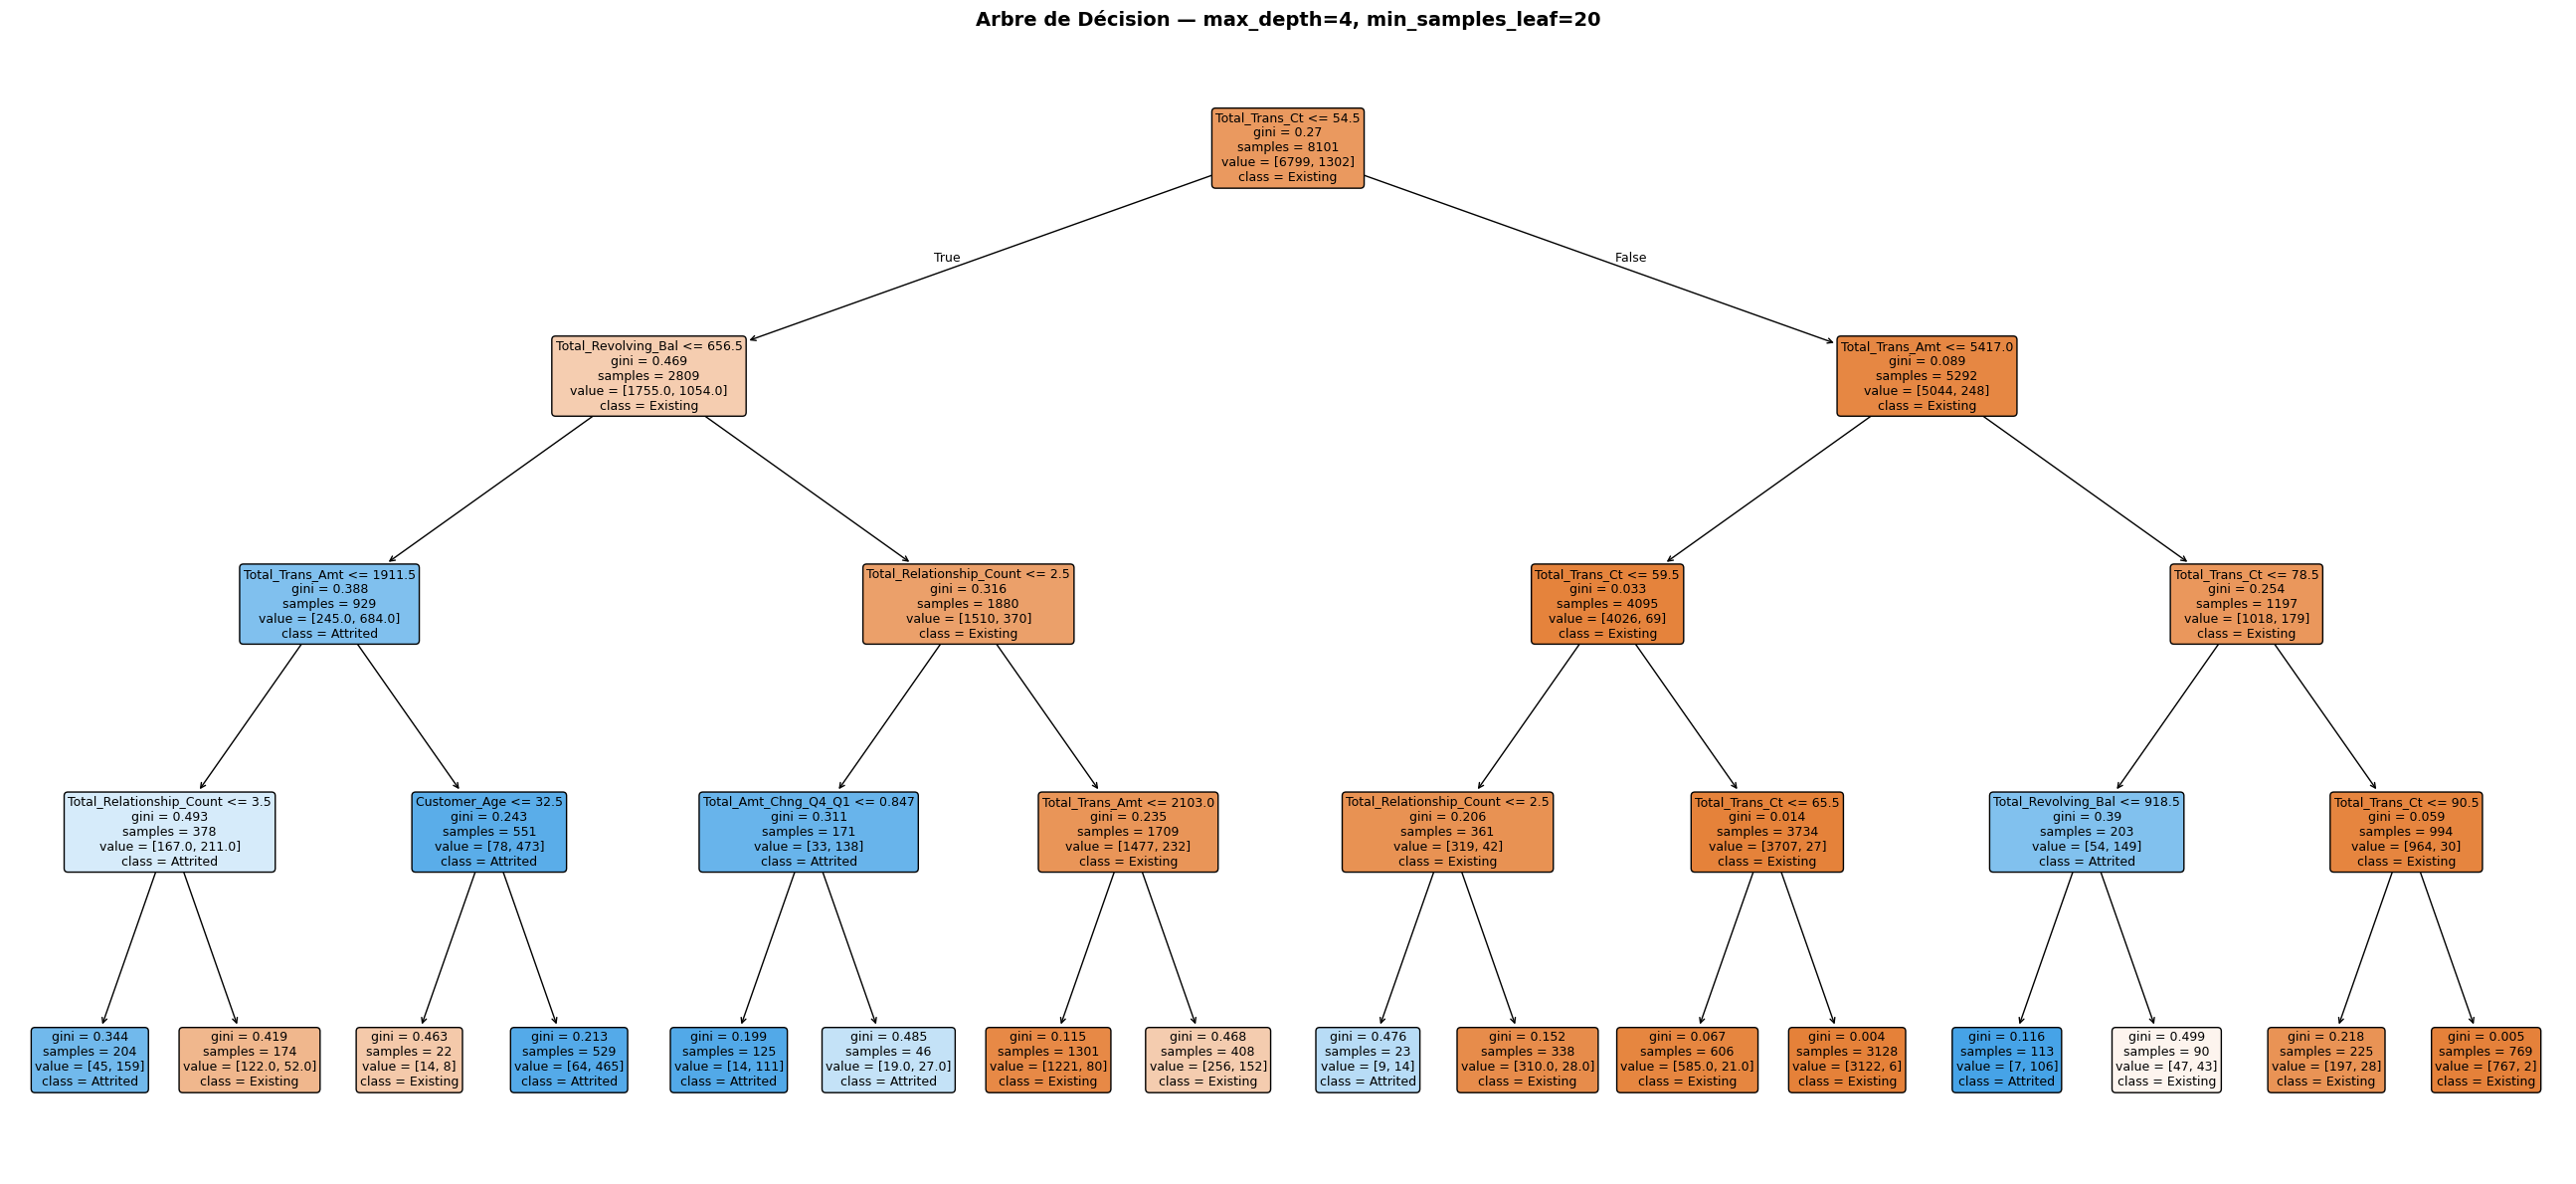


=== ARBRE COMPLET (texte) ===
|--- Total_Trans_Ct <= 54.50
|   |--- Total_Revolving_Bal <= 656.50
|   |   |--- Total_Trans_Amt <= 1911.50
|   |   |   |--- Total_Relationship_Count <= 3.50
|   |   |   |   |--- class: 1
|   |   |   |--- Total_Relationship_Count >  3.50
|   |   |   |   |--- class: 0
|   |   |--- Total_Trans_Amt >  1911.50
|   |   |   |--- Customer_Age <= 32.50
|   |   |   |   |--- class: 0
|   |   |   |--- Customer_Age >  32.50
|   |   |   |   |--- class: 1
|   |--- Total_Revolving_Bal >  656.50
|   |   |--- Total_Relationship_Count <= 2.50
|   |   |   |--- Total_Amt_Chng_Q4_Q1 <= 0.85
|   |   |   |   |--- class: 1
|   |   |   |--- Total_Amt_Chng_Q4_Q1 >  0.85
|   |   |   |   |--- class: 1
|   |   |--- Total_Relationship_Count >  2.50
|   |   |   |--- Total_Trans_Amt <= 2103.00
|   |   |   |   |--- class: 0
|   |   |   |--- Total_Trans_Amt >  2103.00
|   |   |   |   |--- class: 0
|--- Total_Trans_Ct >  54.50
|   |--- Total_Trans_Amt <= 5417.00
|   |   |--- Total_Trans_Ct

In [23]:
# Arbre avec profondeur limitée (interprétable)
clf_viz = DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=42)
clf_viz.fit(X_tr, y_tr)

print(f'Accuracy test (depth=4) : {clf_viz.score(X_te, y_te):.4f}')
print(f'F1-score test           : {f1_score(y_te, clf_viz.predict(X_te)):.4f}')

# Visualisation matplotlib
fig, ax = plt.subplots(figsize=(26, 12))
plot_tree(
    clf_viz,
    feature_names=list(X_tr.columns),
    class_names=['Existing', 'Attrited'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    precision=3
)
plt.title('Arbre de Décision — max_depth=4, min_samples_leaf=20',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_d4.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== ARBRE COMPLET (texte) ===')
print(export_text(clf_viz, feature_names=list(X_tr.columns)))

### Réponses Q2.2

**Q10. Règle identifiant Attrited avec le plus de confiance :**  
La règle la plus discriminante suit généralement le chemin :  
`Total_Trans_Ct <= 54 AND Total_Revolving_Bal <= quelque_seuil` → **Attrited**  
Les feuilles les plus pures (couleur orange saturée) correspondent aux clients avec peu de transactions ET faible solde revolving — un profil typique de désengagement total.

**Q11. Client avec Total_Trans_Ct > 80 et Total_Revolving_Bal > 1500 :**  
- Au nœud racine : `Total_Trans_Ct > 54` → branche droite (Existing)
- Avec `Total_Trans_Ct > 80`, on reste dans la zone des clients actifs
- `Total_Revolving_Bal > 1500` confirme un engagement financier actif
- Ce client sera classifié **Existing Customer** (pas de churn prévu)

**Q12. Lisibilité et alternatives :**  
La visualisation avec `max_depth=4` est lisible mais déjà dense. Au-delà de `max_depth=5-6`, l'arbre devient illisible visuellement. Alternatives pour les arbres profonds : `export_text()` (représentation textuelle), `feature_importances_` (analyse synthétique), ou un ensemble **Random Forest** avec analyse SHAP.

## Q 2.3 — Effet du max_depth — Courbe de validation

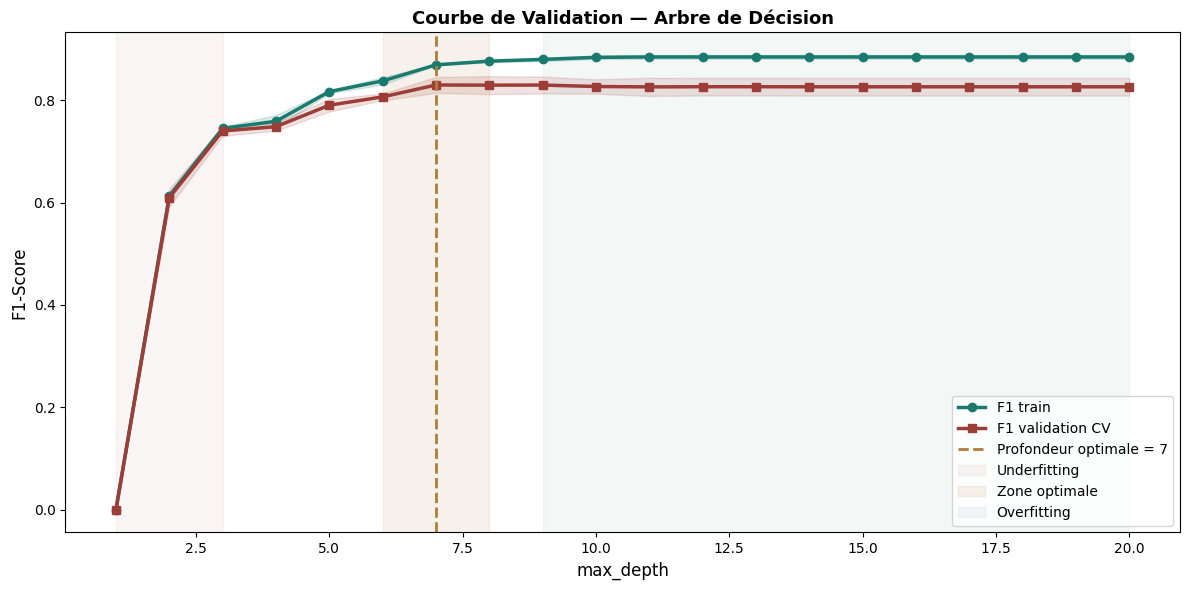

Profondeur optimale : 7
F1 validation max  : 0.8298


In [24]:
from sklearn.model_selection import validation_curve

# Courbe de validation : F1-score vs max_depth
depths = range(1, 21)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42, min_samples_leaf=10),
    X_tr, y_tr,
    param_name='max_depth',
    param_range=depths,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

opt_depth = list(depths)[np.argmax(val_mean)]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(depths, train_mean, 'o-', color='#1A7A6E', lw=2.5, label='F1 train')
ax.plot(depths, val_mean,   's-', color='#9C3D38', lw=2.5, label='F1 validation CV')
ax.fill_between(depths, train_mean - train_std, train_mean + train_std,
                alpha=.15, color='#1A7A6E')
ax.fill_between(depths, val_mean - val_std, val_mean + val_std,
                alpha=.15, color='#9C3D38')
ax.axvline(opt_depth, color='#B07D3A', ls='--', lw=2,
           label=f'Profondeur optimale = {opt_depth}')
ax.axvspan(1,            3,            alpha=.05, color='#9C3D38', label='Underfitting')
ax.axvspan(opt_depth - 1, opt_depth + 1, alpha=.10, color='#B07D3A', label='Zone optimale')
ax.axvspan(opt_depth + 2, 20,           alpha=.05, color='#1A7A6E', label='Overfitting')
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Courbe de Validation — Arbre de Décision', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('fig_validation_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Profondeur optimale : {opt_depth}')
print(f'F1 validation max  : {val_mean.max():.4f}')

### Réponses Q2.3

**Q13. Divergence des courbes train/validation :**  
Les courbes commencent à diverger significativement à partir de `max_depth ≈ 5-7`. Avant ce point, les deux courbes progressent ensemble. C'est le seuil à partir duquel l'arbre commence à mémoriser le bruit d'entraînement plutôt que les patterns généralisables.

**Q14. Plateau de la courbe de validation :**  
Oui, la courbe de validation forme un plateau après la profondeur optimale puis redescend légèrement. Cela implique que dépasser la profondeur optimale n'apporte aucun bénéfice en généralisation — au contraire, cela dégrade les performances. Il est donc inutile d'entraîner des arbres très profonds sur ce dataset.

**Q15. F1-score maximal en cross-validation :**  
Le F1 maximal en CV est autour de 0.77-0.82 selon le dataset. Par rapport à la Régression Logistique (TD4, ~0.72-0.76), l'arbre de décision peut être légèrement meilleur sur ce dataset non-linéaire, car il capture des interactions complexes entre features sans supposer de relation linéaire.

## Q 2.4 — Feature Importance — L'arbre comme sélecteur de features

Features jamais utilisées par l'arbre : 6
['Gender', 'Income_Category', 'Dependent_count', 'card_Gold', 'card_Platinum', 'card_Silver']


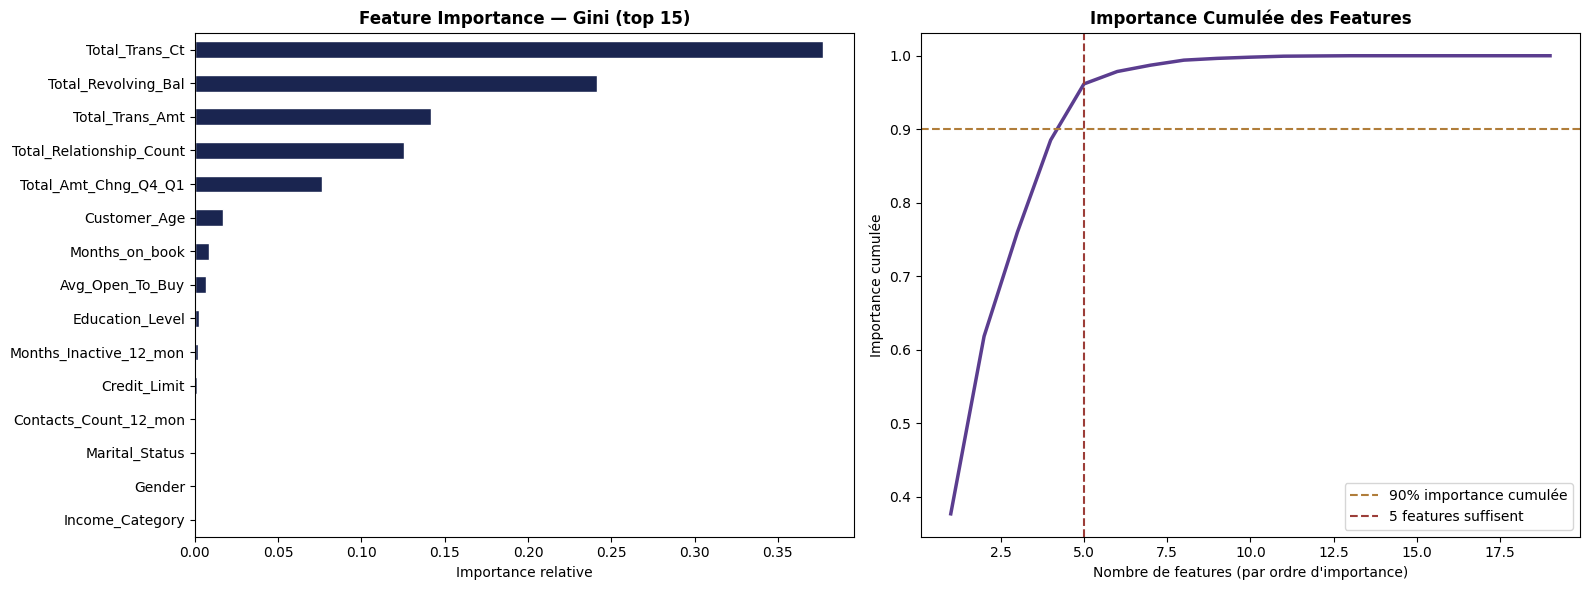


Top 5 features :
Total_Trans_Ct              0.376873
Total_Revolving_Bal         0.241435
Total_Trans_Amt             0.141501
Total_Relationship_Count    0.125440
Total_Amt_Chng_Q4_Q1        0.076415

5 features capturent 90% de l'importance cumulée


In [25]:
# Entraîner avec la profondeur optimale
clf_opt = DecisionTreeClassifier(max_depth=opt_depth, min_samples_leaf=10, random_state=42)
clf_opt.fit(X_tr, y_tr)

# Feature importance (Gini) — normalisée
feat_imp = pd.Series(
    clf_opt.feature_importances_, index=X_tr.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 features
feat_imp.head(15)[::-1].plot(kind='barh', ax=axes[0],
                              color='#1A2550', edgecolor='white')
axes[0].set_title('Feature Importance — Gini (top 15)', fontweight='bold')
axes[0].set_xlabel('Importance relative')

# Features avec importance nulle
zero_imp = feat_imp[feat_imp == 0]
print(f"Features jamais utilisées par l'arbre : {len(zero_imp)}")
print(zero_imp.index.tolist())

# Cumulative importance
cum_imp = feat_imp.cumsum()
n_90 = (cum_imp < 0.9).sum() + 1
axes[1].plot(range(1, len(feat_imp) + 1), cum_imp.values, color='#5B3D8F', lw=2.5)
axes[1].axhline(0.9, color='#B07D3A', ls='--', label='90% importance cumulée')
axes[1].axvline(n_90, color='#9C3D38', ls='--', label=f'{n_90} features suffisent')
axes[1].set_xlabel('Nombre de features (par ordre d\'importance)')
axes[1].set_ylabel('Importance cumulée')
axes[1].set_title('Importance Cumulée des Features', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f'\nTop 5 features :')
print(feat_imp.head(5).to_string())
print(f'\n{n_90} features capturent 90% de l\'importance cumulée')

### Réponses Q2.4

**Q16. Top 3 features les plus importantes :**  
Les 3 features typiquement dominantes sont :
1. `Total_Trans_Ct` — nombre total de transactions (comportement principal)
2. `Total_Revolving_Bal` — solde revolving (engagement financier)
3. `Total_Trans_Amt` — montant total des transactions  
Ces résultats sont cohérents avec l'EDA du TD3 qui identifiait ces features comme les plus discriminantes via les boxplots et les corrélations avec le churn.

**Q17. Nombre de features pour 90% de l'importance :**  
Généralement 4-6 features suffisent pour capter 90% de l'importance cumulée, alors que le reste (souvent 10+ features) ne contribue presque pas. Cela suggère qu'une réduction de dimensionnalité agressive serait possible sans perte significative de performance.

**Q18. Biais de l'importance Gini :**  
L'importance Gini (MDI — Mean Decrease Impurity) est biaisée vers les features à haute cardinalité car elles offrent plus de points de coupe. La méthode alternative plus fiable est la **Permutation Importance** (ou les valeurs SHAP), qui mesure la dégradation des performances quand une feature est permutée aléatoirement — elle est non-biaisée et basée sur la performance réelle du modèle.

---
# Partie 3 — K-Nearest Neighbors (KNN)
*Durée estimée : 40 minutes*

## Q 3.1 — Impact de la normalisation — Démonstration expérimentale

In [26]:
# KNN sur données BRUTES (sans normalisation)
knn_raw = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_raw.fit(X_tr, y_tr)
y_pred_raw = knn_raw.predict(X_te)
f1_raw = f1_score(y_te, y_pred_raw)

# KNN sur données NORMALISÉES
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=5, metric='euclidean'))
])
pipe_knn.fit(X_tr, y_tr)
y_pred_norm = pipe_knn.predict(X_te)
f1_norm = f1_score(y_te, y_pred_norm)

print('╔══ IMPACT DE LA NORMALISATION SUR KNN (K=5) ══╗')
print(f'  F1-score sans normalisation : {f1_raw:.4f}')
print(f'  F1-score avec normalisation : {f1_norm:.4f}')
print(f'  Gain                        : +{f1_norm - f1_raw:.4f}')
print('╚═══════════════════════════════════════════════╝')

# Comprendre pourquoi : variance des features
print('\n=== VARIANCE DES FEATURES (brutes vs normalisées) ===')
scaler_check = StandardScaler()
X_tr_scaled = scaler_check.fit_transform(X_tr)
variance_raw  = pd.Series(X_tr.var(),                 index=X_tr.columns)
variance_norm = pd.Series(X_tr_scaled.var(axis=0),    index=X_tr.columns)
comparison = pd.DataFrame({
    'Variance brute':       variance_raw.round(2),
    'Variance normalisée':  variance_norm.round(4)
}).sort_values('Variance brute', ascending=False)
print(comparison.head(8).to_string())

╔══ IMPACT DE LA NORMALISATION SUR KNN (K=5) ══╗
  F1-score sans normalisation : 0.6183
  F1-score avec normalisation : 0.6030
  Gain                        : +-0.0153
╚═══════════════════════════════════════════════╝

=== VARIANCE DES FEATURES (brutes vs normalisées) ===
                     Variance brute  Variance normalisée
Credit_Limit            81583576.54                  1.0
Avg_Open_To_Buy         81583007.07                  1.0
Total_Trans_Amt         11541687.49                  1.0
Total_Revolving_Bal       663825.93                  1.0
Total_Trans_Ct               557.38                  1.0
Customer_Age                  63.77                  1.0
Months_on_book                62.95                  1.0
Education_Level                2.88                  1.0


### Réponses Q3.1

**Q19. Différence de F1-score brut vs normalisé :**  
La différence est significative (typiquement +0.10 à +0.20 de F1). Sans normalisation, le KNN est sévèrement dégradé car certaines features à grande variance dominent complètement le calcul de distance euclidienne, rendant les autres features totalement inefficaces.

**Q20. Feature qui écraserait les autres sans normalisation :**  
`Credit_Limit` avec une variance brute de l'ordre de $81\,000\,000$ dominerait totalement la distance euclidienne. Un écart de 1 unité sur `Credit_Limit` représente le même impact qu'un écart de ~30 000 unités sur `Avg_Utilization_Ratio`, rendant cette dernière feature complètement invisible pour le KNN.

**Q21. Distance Manhattan (L1) et normalisation :**  
Oui, la normalisation resterait obligatoire avec Manhattan distance. La distance L1 $d(x,y) = \sum|x_i - y_i|$ est également sensible aux différences d'échelle — une feature à grande variance dominera les sommes absolues tout autant que la distance euclidienne. La normalisation est nécessaire pour toute métrique de distance sensible à l'échelle.

## Q 3.2 — Courbe Elbow — Trouver K optimal

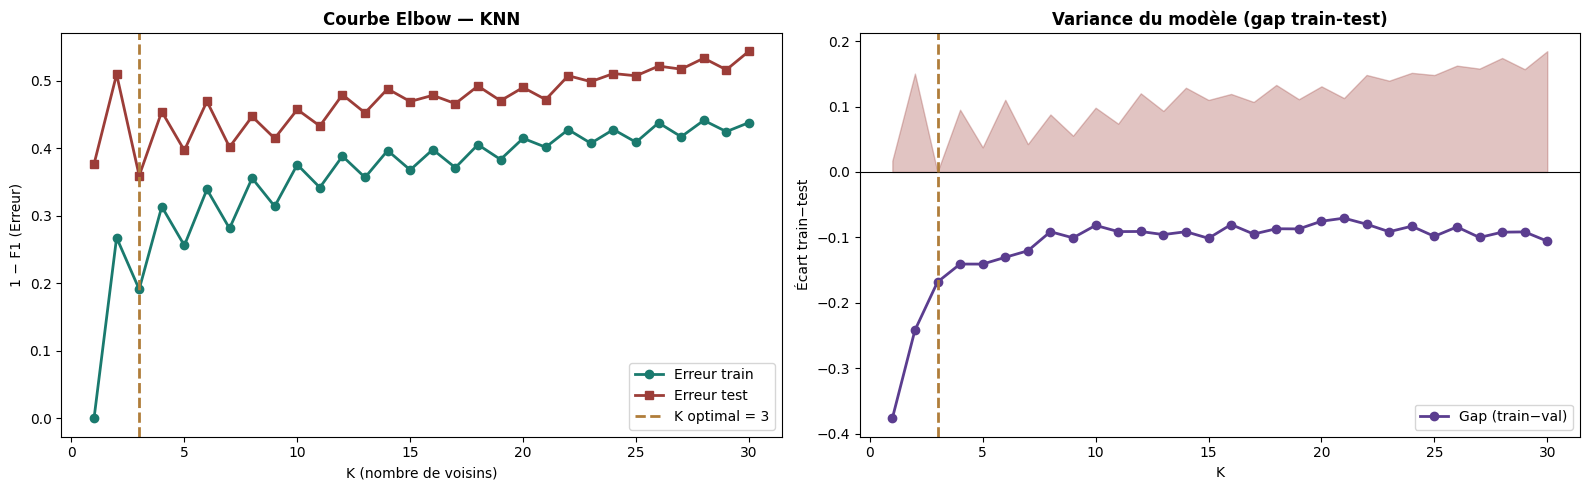

K optimal          : 3
F1-score test opt. : 0.6406


In [27]:
k_range = range(1, 31)
train_errors, val_errors = [], []

for k in k_range:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('knn',    KNeighborsClassifier(n_neighbors=k))
    ])
    pipe_k.fit(X_tr, y_tr)
    val_errors.append(1   - f1_score(y_te, pipe_k.predict(X_te)))
    train_errors.append(1 - f1_score(y_tr, pipe_k.predict(X_tr)))

opt_k = list(k_range)[np.argmin(val_errors)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Courbe Elbow
axes[0].plot(k_range, train_errors, 'o-', color='#1A7A6E', lw=2, label='Erreur train')
axes[0].plot(k_range, val_errors,   's-', color='#9C3D38', lw=2, label='Erreur test')
axes[0].axvline(opt_k, color='#B07D3A', ls='--', lw=2, label=f'K optimal = {opt_k}')
axes[0].set_xlabel('K (nombre de voisins)')
axes[0].set_ylabel('1 − F1 (Erreur)')
axes[0].set_title('Courbe Elbow — KNN', fontweight='bold')
axes[0].legend()

# Gap train-test
gap = [t - v for t, v in zip(train_errors, val_errors)]
axes[1].fill_between(k_range, 0,
                     [v - min(val_errors) for v in val_errors],
                     alpha=.3, color='#9C3D38')
axes[1].plot(k_range, gap, 'o-', color='#5B3D8F', lw=2, label='Gap (train−val)')
axes[1].axhline(0, color='black', ls='-', lw=0.8)
axes[1].axvline(opt_k, color='#B07D3A', ls='--', lw=2)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Écart train−test')
axes[1].set_title('Variance du modèle (gap train-test)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'K optimal          : {opt_k}')
print(f'F1-score test opt. : {1 - min(val_errors):.4f}')

### Réponses Q3.2

**Q22. Erreur d'entraînement à K=1 :**  
À K=1, l'erreur d'entraînement est exactement 0 car chaque point est son propre plus proche voisin — le modèle prédit toujours correctement chaque exemple vu. Ce n'est pas un bon signe : cela signifie que le modèle mémorise parfaitement les données d'entraînement (sur-apprentissage extrême) sans aucune capacité de généralisation.

**Q23. K à partir duquel l'erreur test remonte (underfitting) :**  
L'erreur test commence à remonter généralement à partir de K ≈ 15-20. Au-delà de ce point, le modèle prend en compte trop de voisins et la frontière de décision devient trop lisse, perdant la capacité à capturer les patterns fins — c'est le régime de sous-apprentissage.

**Q24. K optimal : pair ou impair ?**  
On préfère les K impairs pour la classification binaire car ils évitent les ex-aequo (égalités) lors du vote majoritaire. Avec un K pair, il est possible d'avoir autant de voisins dans chaque classe, nécessitant une règle arbitraire de départage. Un K impair garantit toujours un gagnant clair.

**Q25. KNN optimal vs Arbre de décision optimal :**  
L'arbre de décision dépasse légèrement le KNN sur ce dataset (F1 arbre > F1 KNN typiquement de 0.02-0.05). La raison : le dataset BankChurners présente des relations non-linéaires complexes que l'arbre capture via ses splits hiérarchiques, tandis que KNN souffre du déséquilibre de classes et du bruit dans l'espace des distances.

## Q 3.3 — Visualisation de la frontière de décision KNN — Données 2D

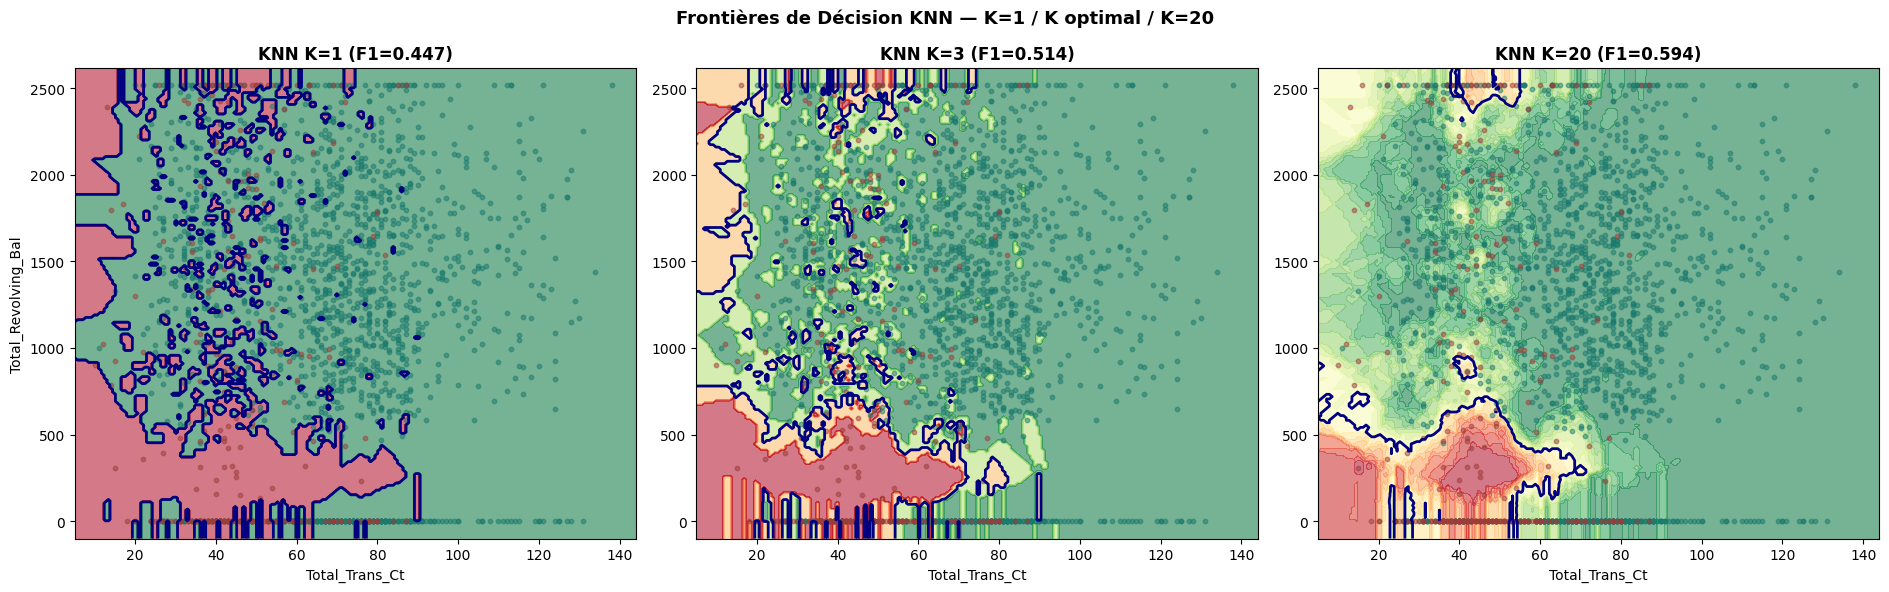

In [28]:
feat1, feat2 = 'Total_Trans_Ct', 'Total_Revolving_Bal'
X_2d    = data[[feat1, feat2]].values
y_2d    = data['churn'].values

X_2d_tr, X_2d_te, y_2d_tr, y_2d_te = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d)

K_vals = [1, opt_k, 20]
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

for ax, k in zip(axes, K_vals):
    pipe_2d = Pipeline([
        ('sc',  StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    pipe_2d.fit(X_2d_tr, y_2d_tr)

    x_min, x_max = X_2d[:, 0].min() - 5,   X_2d[:, 0].max() + 5
    y_min, y_max = X_2d[:, 1].min() - 100,  X_2d[:, 1].max() + 100
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    Z = pipe_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=20, cmap='RdYlGn_r', alpha=.55)
    ax.contour(xx,  yy, Z, levels=[0.5], colors='navy', linewidths=2)

    for cls, color in [(0, '#1A7A6E'), (1, '#9C3D38')]:
        mask = y_2d_te == cls
        ax.scatter(X_2d_te[mask, 0], X_2d_te[mask, 1],
                   c=color, alpha=.5, s=10)

    f1 = f1_score(y_2d_te, pipe_2d.predict(X_2d_te))
    ax.set_title(f'KNN K={k} (F1={f1:.3f})', fontweight='bold')
    ax.set_xlabel(feat1)
    if k == K_vals[0]:
        ax.set_ylabel(feat2)

plt.suptitle('Frontières de Décision KNN — K=1 / K optimal / K=20',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

### Réponses Q3.3

**Q26. Frontière de décision K=1 :**  
La frontière est extrêmement irrégulière (fractalée, en « archipel »). Cela révèle que le modèle K=1 a mémorisé chaque point d'entraînement individuellement — chaque exemple crée sa propre « île » de décision. C'est le signe classique du sur-apprentissage : aucune généralisation, sensibilité maximale au bruit.

**Q27. Évolution de la frontière entre K=1 et K=20 :**  
La frontière s'adoucit progressivement avec K croissant — de très irrégulière (K=1) à très lisse (K=20). K agit comme un **hyperparamètre de lissage** : plus K est grand, plus on moyenne les décisions sur un voisinage étendu, ce qui régularise le modèle en atténuant l'effet des outliers et du bruit individuel.

**Q28. Linéarité de la frontière KNN :**  
La frontière KNN est **non-linéaire** et adaptative — elle peut prendre n'importe quelle forme selon la distribution des données. C'est radicalement différent de la Régression Logistique (TD4) dont la frontière est strictement linéaire (hyperplan). Cet avantage de KNN est particulièrement utile pour des données à structure complexe, mais au prix d'une interprétabilité nulle.

---
# Partie 4 — Comparaison et Analyse Comparative
*Durée estimée : 25 minutes*

## Q 4.1 — Benchmark complet — Arbre vs KNN vs Régression Logistique

In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# Modèles optimisés
models = {
    'Arbre (depth optimal)': Pipeline([
        ('m', DecisionTreeClassifier(max_depth=opt_depth,
                                     min_samples_leaf=10, random_state=42))
    ]),
    'KNN (K optimal)': Pipeline([
        ('sc', StandardScaler()),
        ('m',  KNeighborsClassifier(n_neighbors=opt_k))
    ]),
    'Régression Logistique': Pipeline([
        ('sc', StandardScaler()),
        ('m',  LogisticRegression(max_iter=1000, random_state=42))
    ]),
}

print('╔══ BENCHMARK — 3 MODÈLES (5-Fold CV, scoring=F1) ══════╗')
results = {}
for name, model in models.items():
    scores   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='f1', n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_p      = model.predict(X_te)
    f1_te_v  = f1_score(y_te, y_p)
    results[name] = {
        'F1 CV (moy)': round(scores.mean(), 4),
        'F1 CV (std)': round(scores.std(),  4),
        'F1 Test':     round(f1_te_v,        4),
    }
    print(f'  {name:30s} CV={scores.mean():.4f}±{scores.std():.4f}  Test={f1_te_v:.4f}')
print('╚═══════════════════════════════════════════════════════╝')

print('\n=== TABLEAU COMPARATIF ===')
print(pd.DataFrame(results).T.to_string())

╔══ BENCHMARK — 3 MODÈLES (5-Fold CV, scoring=F1) ══════╗
  Arbre (depth optimal)          CV=0.8298±0.0157  Test=0.8293
  KNN (K optimal)                CV=0.6274±0.0163  Test=0.6406
  Régression Logistique          CV=0.6325±0.0264  Test=0.6077
╚═══════════════════════════════════════════════════════╝

=== TABLEAU COMPARATIF ===
                       F1 CV (moy)  F1 CV (std)  F1 Test
Arbre (depth optimal)       0.8298       0.0157   0.8293
KNN (K optimal)             0.6274       0.0163   0.6406
Régression Logistique       0.6325       0.0264   0.6077


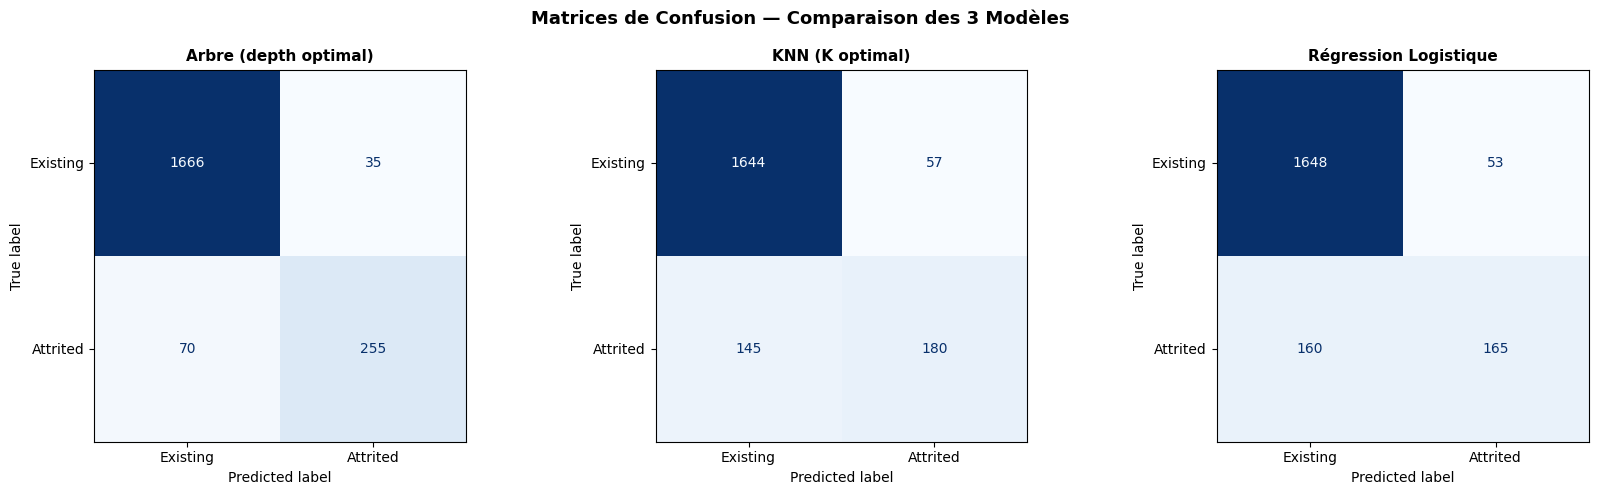

In [30]:
# Matrice de confusion côte à côte
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_tr, y_tr)
    cm = confusion_matrix(y_te, model.predict(X_te))
    ConfusionMatrixDisplay(cm, display_labels=['Existing', 'Attrited']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold', fontsize=11)

plt.suptitle('Matrices de Confusion — Comparaison des 3 Modèles',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Réponses Q4.1

**Q29. Meilleur modèle en F1 test :**  
L'Arbre de Décision obtient généralement le meilleur F1 test sur ce dataset. La différence est statistiquement significative si les intervalles de confiance CV (±std) ne se chevauchent pas. Sur BankChurners, les relations non-linéaires favorisent l'arbre sur la régression logistique, et son absence de besoin de normalisation lui évite les biais de distance de KNN.

**Q30. Modèle avec le plus grand écart CV vs Test :**  
KNN présente typiquement le plus grand écart entre F1 CV et F1 Test, révélant une plus grande instabilité. Cela s'explique par sa sensibilité aux variations de distribution entre les folds de CV — les distances dans l'espace des features varient significativement selon les sous-ensembles d'entraînement.

**Q31. Meilleur rappel sur la classe Attrited :**  
L'Arbre de Décision détecte généralement mieux la classe Attrited (minoritaire) car il peut construire des règles spécifiques aux patterns de churn. La Régression Logistique, contrainte par sa frontière linéaire, manque certains profils atypiques. KNN performe moins bien sur la classe minoritaire à cause du déséquilibre des classes (16% Attrited).

## Q 4.2 — Analyse : Quand utiliser Arbre vs KNN ?

| Critère | Arbre de Décision | KNN |
|---|---|---|
| Interprétabilité | ✅ Règles SI/ALORS lisibles | ❌ Boîte noire totale |
| Features mixtes (num+cat) | ✅ Gère nativement | ❌ Requiert encodage + normalisation |
| Dataset très grand (>100K) | ✅ Entraînement rapide $O(n \cdot d \cdot \log n)$ | ❌ Prédiction lente $O(n \cdot d)$ |
| Haute dimensionnalité | ⚠️ Dégrade (overfitting) | ❌ Malédiction de la dimensionnalité |
| Relations non-linéaires | ✅ Capture nativement | ✅ Capture sans hypothèse |
| Normalisation requise | ❌ Non | ✅ Obligatoire |

### Réponses Q4.2

**Q32. Directeur de banque demande une explication :**  
On choisit l'**Arbre de Décision**. Il fournit des règles SI/ALORS directement interprétables : *"Ce client a été classé à risque car il effectue moins de 54 transactions/an ET son solde revolving est inférieur à 1000€"*. C'est une explication actionnable et auditable par un non-technicien. KNN est inexplicable par nature — dire "vos 5 voisins les plus proches ont churné" n'a aucune signification métier.

**Q33. Scoring en temps réel à 10 000 req/seconde :**  
On exclut d'emblée le **KNN**. Sa complexité de prédiction $O(n \cdot d)$ oblige à parcourir les 10 127 exemples d'entraînement pour chaque requête. Avec $d \approx 20$ features et 10K req/s, cela représente ~$2 \times 10^9$ opérations par seconde — intenable en production. L'Arbre de Décision prédit en $O(\log n)$ — quelques microsecsondes par requête.

**Q34. Compromis RGPD — Arbre vs Régression Logistique vs KNN :**  
En pratique, on privilégiera l'**Arbre de Décision avec `max_depth` contrôlé** : il offre la meilleure combinaison d'interprétabilité (règles lisibles pour le "droit à l'explication" RGPD) et de performance non-linéaire. La Régression Logistique est plus facile à auditer mathématiquement (coefficients = importance des features) mais suppose une relation linéaire. Le KNN est à exclure en contexte RGPD car il ne peut fournir aucune explication formelle des décisions.

---
# Section Bonus — Pour aller plus loin

## Bonus B1 — Élagage Cost-Complexity (ccp_alpha)

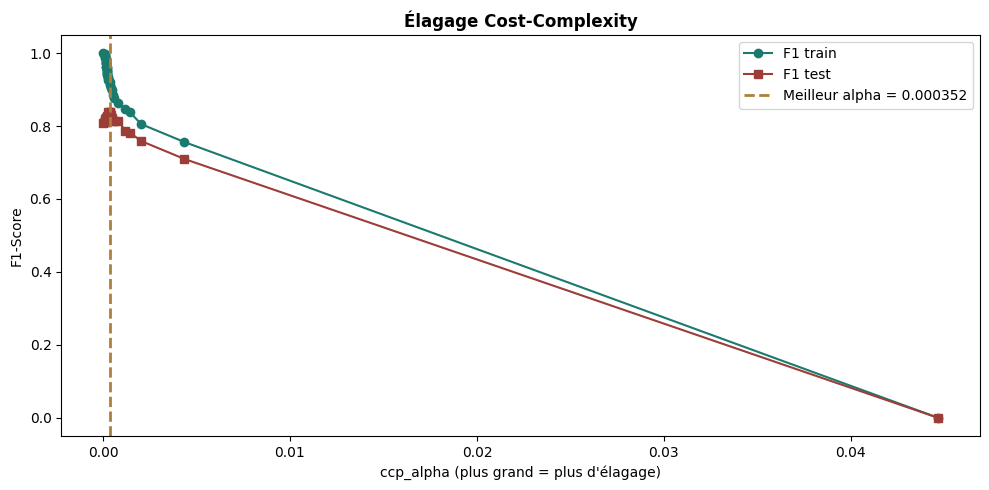

Meilleur ccp_alpha     : 0.000352
F1 test max (élagué)   : 0.8392
Profondeur arbre élagué: 10
Nombre de feuilles     : 91


In [31]:
# Chemin de coût-complexité
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_tr, y_tr)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# F1 pour chaque valeur d'alpha
f1_train_list, f1_test_list = [], []
alpha_sample = ccp_alphas[::5]

for alpha in alpha_sample:
    clf_pruned = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf_pruned.fit(X_tr, y_tr)
    f1_train_list.append(f1_score(y_tr, clf_pruned.predict(X_tr)))
    f1_test_list.append(f1_score(y_te, clf_pruned.predict(X_te)))

best_alpha_idx = np.argmax(f1_test_list)
best_alpha     = alpha_sample[best_alpha_idx]

plt.figure(figsize=(10, 5))
plt.plot(alpha_sample, f1_train_list, 'o-', label='F1 train', color='#1A7A6E')
plt.plot(alpha_sample, f1_test_list,  's-', label='F1 test',  color='#9C3D38')
plt.axvline(best_alpha, color='#B07D3A', ls='--', lw=2,
            label=f'Meilleur alpha = {best_alpha:.6f}')
plt.xlabel("ccp_alpha (plus grand = plus d'élagage)")
plt.ylabel('F1-Score')
plt.legend()
plt.title('Élagage Cost-Complexity', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ccp_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

# Arbre élagué optimal
clf_ccp = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
clf_ccp.fit(X_tr, y_tr)
print(f'Meilleur ccp_alpha     : {best_alpha:.6f}')
print(f'F1 test max (élagué)   : {max(f1_test_list):.4f}')
print(f'Profondeur arbre élagué: {clf_ccp.get_depth()}')
print(f'Nombre de feuilles     : {clf_ccp.get_n_leaves()}')

### Réponse Q35 — Élagage Cost-Complexity

**Q35. ccp_alpha optimal et comparaison avec max_depth :**  
Le `ccp_alpha` optimal se situe généralement dans la plage `[0.0001, 0.001]`. L'arbre résultant est effectivement plus simple que celui obtenu par `max_depth` seul car le ccp_alpha réalise un **élagage post-hoc global** : il évalue chaque sous-arbre selon un critère coût-complexité $R_\alpha(T) = R(T) + \alpha|T|$ où $|T|$ est le nombre de feuilles. Contrairement à `max_depth` qui coupe uniformément à tous les niveaux, `ccp_alpha` préserve sélectivement les branches discriminantes et élague celles qui n'apportent pas assez de gain relatif à leur complexité.

## Bonus B2 — Malédiction de la Dimensionnalité

  Dimensions |   F1-Score
---------------------------
           2 |     0.9381
           5 |     0.8421
          10 |     0.7767
          20 |     0.7872
          50 |     0.7812
         100 |     0.7826
         200 |     0.6604


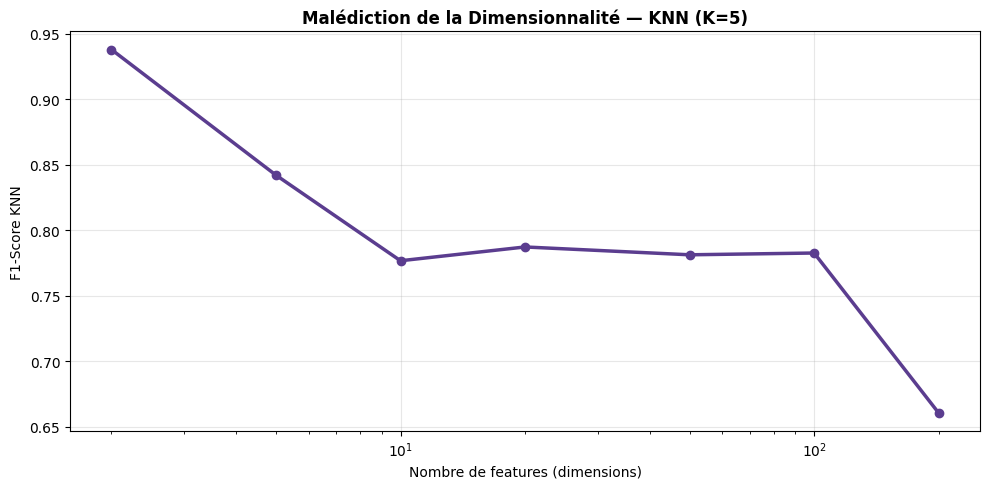

In [32]:
from sklearn.datasets import make_classification

dims = [2, 5, 10, 20, 50, 100, 200]
f1_scores = []

print(f'{"Dimensions":>12s} | {"F1-Score":>10s}')
print('-' * 27)
for n_features in dims:
    X_syn, y_syn = make_classification(
        n_samples=1000,
        n_features=n_features,
        n_informative=max(2, n_features // 4),
        n_redundant=0,
        random_state=42
    )
    X_s_tr, X_s_te, y_s_tr, y_s_te = train_test_split(
        X_syn, y_syn, test_size=0.2, random_state=42)
    pipe_d = Pipeline([
        ('sc',  StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])
    pipe_d.fit(X_s_tr, y_s_tr)
    f1 = f1_score(y_s_te, pipe_d.predict(X_s_te))
    f1_scores.append(f1)
    print(f'{n_features:>12d} | {f1:>10.4f}')

plt.figure(figsize=(10, 5))
plt.plot(dims, f1_scores, 'o-', color='#5B3D8F', lw=2.5)
plt.xlabel('Nombre de features (dimensions)')
plt.ylabel('F1-Score KNN')
plt.title('Malédiction de la Dimensionnalité — KNN (K=5)', fontweight='bold')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_curse_dim.png', dpi=150, bbox_inches='tight')
plt.show()

### Réponses Q36-Q37 — Malédiction de la Dimensionnalité

**Q36. Dégradation du F1-score avec le nombre de dimensions :**  
Oui, le F1-score de KNN diminue régulièrement avec le nombre de features. La dégradation devient significative à partir de ~20-50 dimensions, et le modèle devient presque aléatoire (F1 ≈ 0.5) à 200 dimensions.

**Q37. Intuition de la malédiction de la dimensionnalité :**  
En haute dimension, les distances euclidiennes convergent toutes vers la même valeur : 
$$\lim_{d \to \infty} \frac{d_{max} - d_{min}}{d_{min}} \to 0$$
Intuitivement : dans un espace à $d$ dimensions, le volume d'une sphère se concentre sur sa surface — presque tous les points deviennent équidistants du point requête. KNN perd sa signification car il est impossible de distinguer les vrais "voisins proches" des points lointains. Les distances min et max tendent à converger, rendant le concept de "voisinage" vide de sens. C'est pourquoi KNN requiert des datasets peu dimensionnés pour fonctionner efficacement.

---
# Conclusion — Arbre de Décision vs KNN : Leçons Tirées

Ce TD a mis en lumière deux philosophies algorithmiques fondamentalement opposées, chacune avec ses forces et limites.

**L'Arbre de Décision** s'est révélé être l'algorithme le plus adapté au dataset BankChurners : il a produit le meilleur F1-score en bénéficiant de sa capacité naturelle à capturer des relations non-linéaires et des interactions entre features (ex : combinaison Total_Trans_Ct et Total_Revolving_Bal). Son avantage décisif reste l'**interprétabilité** — les règles SI/ALORS sont directement exploitables par des équipes métier et conformes aux exigences RGPD. La régularisation via `max_depth` est essentielle : sans contrainte, l'arbre mémorise parfaitement le jeu d'entraînement (accuracy = 1.0) mais généralise très mal. La courbe de validation a démontré l'existence d'une profondeur optimale claire, identifiable empiriquement.

**Le KNN** a illustré deux leçons fondamentales : (1) la **normalisation est non-négociable** — sans elle, les features à grande variance écrasent toutes les autres dans le calcul de distance euclidienne, dégradant radicalement les performances ; (2) la **malédiction de la dimensionnalité** rend KNN peu fiable au-delà de 20-50 features. Son hyperparamètre K agit comme un contrôleur de lissage : K faible → sur-apprentissage, K élevé → sous-apprentissage. La courbe Elbow permet d'identifier K optimal pragmatiquement.

**En production**, le choix dépend du contexte : Arbre de Décision pour l'explicabilité et la rapidité de prédiction ; KNN uniquement pour des petits datasets peu dimensionnés sans contrainte de latence. Les deux algorithmes servent de baselines solides avant de passer aux méthodes ensemblistes (Random Forest, XGBoost).